# 00 — Data quality check

Sanity check every one of the 15 recordings in `data-new/` before any analysis
is run. We verify:

1. **Actual duration** matches the expected analysis window.
2. **Channel equality** (`ch0 == ch1`) — in the legend dataset these were raw
   vs device-filtered, but for this 2026-04-24 acquisition they should be
   byte-identical. We assert this and flag any exceptions.
3. **Visual sanity**: full tachogram-less ECG overview + 10 s zoom to catch
   obvious lead-off, clipping, or saturation.

Output: `outputs/tables/quality_check.csv`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

PL.apply_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Sessions available:', len(cfg.SESSION_MAP))

Setup complete. Sessions available: 14


## 1. Loop all sessions

In [2]:
rows = []
for key, folder in cfg.SESSION_MAP.items():
    root = cfg.get_session_path(key)
    win = cfg.FILE_INVENTORY[key]["window"]
    expected_s = win[1] - win[0]

    # Read ch0 + ch1 (entire recording, no window crop)
    _, ecg0 = P.load_ecg(key, ch=0, apply_window=False)
    t, ecg1 = P.load_ecg(key, ch=1, apply_window=False)

    n_hours = sum(1 for p in root.iterdir() if p.is_dir() and p.name.isdigit())
    duration_s = ecg1.size / cfg.FS
    ch_equal = bool(np.array_equal(ecg0, ecg1))

    pk_pct = float(np.max(np.abs(ecg1)))
    # crude clipping check: flag if >5% of samples sit at |max|
    clip_frac = float(np.mean(np.isclose(np.abs(ecg1), pk_pct, atol=1e-6)))

    rows.append(dict(
        key=key, folder=folder, n_hours=n_hours,
        total_samples=int(ecg1.size),
        actual_duration_s=round(duration_s, 2),
        analysis_window_s=f"{win[0]}-{win[1]} ({expected_s:.0f}s)",
        duration_ok=bool(duration_s >= expected_s - 0.5),
        ch0_eq_ch1=ch_equal,
        peak_abs=round(pk_pct, 1),
        clip_fraction=round(clip_frac, 4),
        note=cfg.FILE_INVENTORY[key]["note"],
    ))

df_quality = pd.DataFrame(rows)
df_quality

,key,folder,n_hours,total_samples,actual_duration_s,analysis_window_s,duration_ok,ch0_eq_ch1,peak_abs,clip_fraction,note
0,E1A,20260424_165939_E1A,2,161000,322.0,10.0-310.0 (300s),True,True,3.0,0.0,"supine, post-sleep (repeat supine)"
1,E1B,20260424_170710_E1B,1,160900,321.8,10.0-310.0 (300s),True,True,3.3,0.0,"sitting, 5 min (HF reference for E2/E3)"
2,E1C,20260424_171501_E1C,1,160700,321.4,10.0-310.0 (300s),True,True,3.2,0.0,"standing, 5 min"
3,E2A_insp_1,20260424_172248_E2A_insp_1,1,60600,121.2,0.0-120.0 (120s),True,True,6.5,0.0,inspiratory hold trial 1
4,E2A_insp_2,20260424_172917_E2A_insp_2,1,60700,121.4,0.0-120.0 (120s),True,True,6.5,0.0,inspiratory hold trial 2
5,E2B_exp_1,20260424_173443_E2B_exp_1,1,60800,121.6,0.0-120.0 (120s),True,True,6.0,0.0,expiratory hold trial 1
6,E2B_exp_2,20260424_174141_E2B_exp_2,1,60600,121.2,0.0-120.0 (120s),True,True,5.5,0.0,expiratory hold trial 2
7,E3_walk,20260424_174736_E3_walk_1,1,90300,180.6,0.0-180.0 (180s),True,True,4.0,0.0,"0-60s seated, 60-120s walk, 120-180s recovery"
8,E4A_12pm,20260424_175610_E4A_12pm,2,120000,240.0,10.0-230.0 (220s),True,True,5.3,0.0,12/min paced breathing
9,E4A_9pm,20260424_180659_E4A_9pm,1,120400,240.8,10.0-230.0 (220s),True,True,5.7,0.0,9/min paced breathing


## 2. Assertions

In [3]:
assert df_quality["ch0_eq_ch1"].all(), (
    "ch0 and ch1 differ on: " +
    ", ".join(df_quality.loc[~df_quality["ch0_eq_ch1"], "key"]))
assert df_quality["duration_ok"].all(), (
    "Recordings shorter than analysis window: " +
    ", ".join(df_quality.loc[~df_quality["duration_ok"], "key"]))
print("All 15 recordings pass duration + ch0==ch1 assertions.")

All 15 recordings pass duration + ch0==ch1 assertions.


## 3. Visual sanity — ECG full overview + 10 s zoom

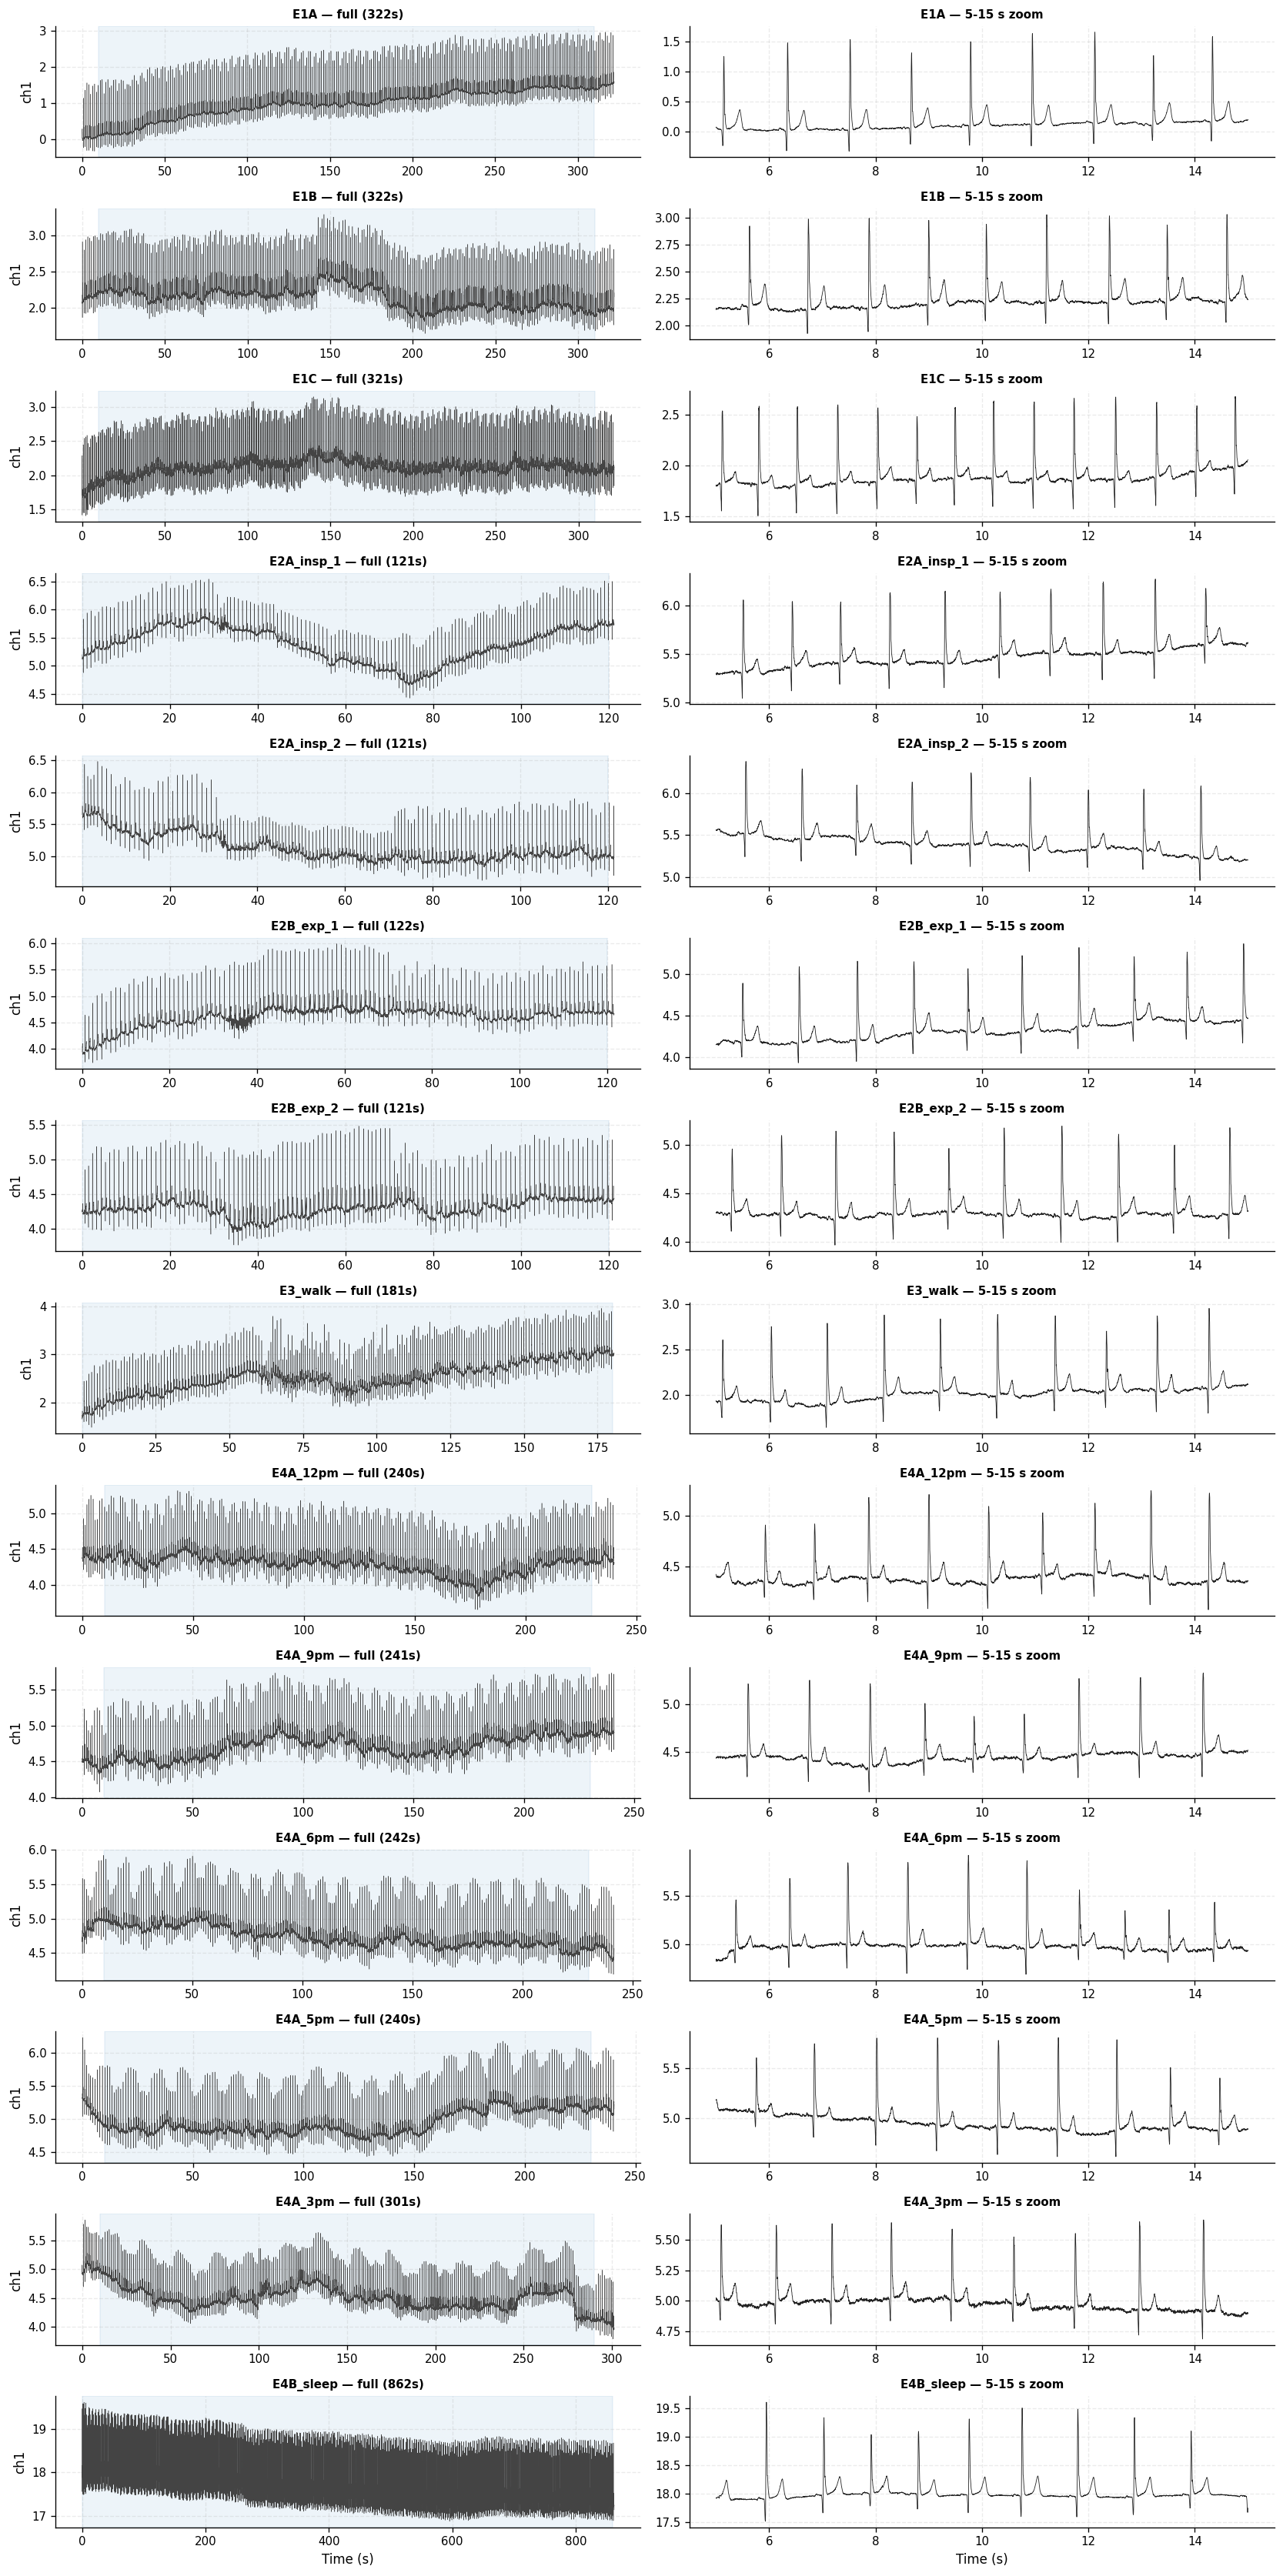

In [ ]:
n = len(cfg.SESSION_MAP)
fig, axes = plt.subplots(n, 2, figsize=(14, 2.0 * n))
for i, key in enumerate(cfg.SESSION_MAP):
    t_full, ecg_full = P.load_ecg(key, ch=1, apply_window=False)
    axes[i, 0].plot(t_full, ecg_full, linewidth=0.3, color="#444")
    w = cfg.FILE_INVENTORY[key]["window"]
    axes[i, 0].axvspan(w[0], w[1], color="tab:blue", alpha=0.08)
    axes[i, 0].set_title(f"{key} — full ({ecg_full.size/cfg.FS:.0f}s)", fontsize=9)
    axes[i, 0].set_ylabel("ch1")

    zoom_start = int(5 * cfg.FS)
    zoom_end = int(15 * cfg.FS)
    axes[i, 1].plot(t_full[zoom_start:zoom_end], ecg_full[zoom_start:zoom_end],
                    linewidth=0.5, color="#222")
    axes[i, 1].set_title(f"{key} — 5-15 s zoom", fontsize=9)
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

## 4. Save table

In [5]:
out_path = TBL_DIR / "quality_check.csv"
df_quality.to_csv(out_path, index=False)
print(f"Wrote {out_path}")
df_quality.style.set_caption("Quality check — 15 sessions")

Wrote /Users/wupeien/Developer/hw5_ecg-analysis/outputs/tables/quality_check.csv


,key,folder,n_hours,total_samples,actual_duration_s,analysis_window_s,duration_ok,ch0_eq_ch1,peak_abs,clip_fraction,note
0,E1A,20260424_165939_E1A,2,161000,322.000000,10.0-310.0 (300s),True,True,3.000000,0.000000,"supine, post-sleep (repeat supine)"
1,E1B,20260424_170710_E1B,1,160900,321.800000,10.0-310.0 (300s),True,True,3.300000,0.000000,"sitting, 5 min (HF reference for E2/E3)"
2,E1C,20260424_171501_E1C,1,160700,321.400000,10.0-310.0 (300s),True,True,3.200000,0.000000,"standing, 5 min"
3,E2A_insp_1,20260424_172248_E2A_insp_1,1,60600,121.200000,0.0-120.0 (120s),True,True,6.500000,0.000000,inspiratory hold trial 1
4,E2A_insp_2,20260424_172917_E2A_insp_2,1,60700,121.400000,0.0-120.0 (120s),True,True,6.500000,0.000000,inspiratory hold trial 2
5,E2B_exp_1,20260424_173443_E2B_exp_1,1,60800,121.600000,0.0-120.0 (120s),True,True,6.000000,0.000000,expiratory hold trial 1
6,E2B_exp_2,20260424_174141_E2B_exp_2,1,60600,121.200000,0.0-120.0 (120s),True,True,5.500000,0.000000,expiratory hold trial 2
7,E3_walk,20260424_174736_E3_walk_1,1,90300,180.600000,0.0-180.0 (180s),True,True,4.000000,0.000000,"0-60s seated, 60-120s walk, 120-180s recovery"
8,E4A_12pm,20260424_175610_E4A_12pm,2,120000,240.000000,10.0-230.0 (220s),True,True,5.300000,0.000000,12/min paced breathing
9,E4A_9pm,20260424_180659_E4A_9pm,1,120400,240.800000,10.0-230.0 (220s),True,True,5.700000,0.000000,9/min paced breathing
